# 5.24 — Evaluating Regression Models Using MSE and $R^2$

After training a regression model, you should answer two questions:

- **How large are the prediction errors?** (MSE / RMSE)
- **How much of the target variation does the model explain?** ($R^2$)

MSE is an absolute error metric (in **squared** target units). RMSE is the square root of MSE (in the **same units** as the target). $R^2$ is a **relative** metric: performance compared to always predicting the mean.

## 1) Setup: Imports, reproducibility, display

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Ensure the repository root (folder containing `src/`) is on sys.path
cwd = Path.cwd().resolve()
for p in [cwd, *cwd.parents]:
    if (p / "src").is_dir():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Could not find repository root containing 'src/'")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.config import (
    ALL_FEATURES,
    CATEGORICAL_FEATURES,
    EXCLUDED_COLUMNS,
    NUMERICAL_FEATURES,
    TARGET_SOURCE_COLUMN,
)
from src.data_loader import load_training_frame
from src.preprocessing import separate_features_and_target

RANDOM_STATE = 42

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)


## 2) Load or generate a regression dataset

This notebook defaults to the project dataset (via `load_training_frame()`).

If you want a larger dataset to make cross-validation more meaningful, you can switch to a synthetic dataset.

In [2]:
USE_SYNTHETIC = False

if USE_SYNTHETIC:
    from sklearn.datasets import make_regression

    X_np, y_np = make_regression(
        n_samples=500,
        n_features=6,
        noise=25.0,
        random_state=RANDOM_STATE,
    )
    X = pd.DataFrame(X_np, columns=[f"x{i}" for i in range(X_np.shape[1])])
    y = pd.Series(y_np, name="target")
else:
    df = load_training_frame()

    X, y = separate_features_and_target(
        df,
        target_column=TARGET_SOURCE_COLUMN,
        feature_columns=[c for c in ALL_FEATURES if c in df.columns],
        excluded_columns=EXCLUDED_COLUMNS,
    )

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("Missing values in X:", int(X.isna().sum().sum()))
print("Missing values in y:", int(pd.isna(y).sum()))

y.describe()

X shape: (4, 3)
y shape: (4,)
y dtype: int64
Missing values in X: 0
Missing values in y: 0


count       4.0000
mean      950.0000
std       208.1666
min       700.0000
25%       850.0000
50%       950.0000
75%      1050.0000
max      1200.0000
Name: yield_kg, dtype: float64

## 3) Train/test split and basic sanity checks

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes: ", X_test.shape, y_test.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_train.shape[1] == X_test.shape[1]

Train shapes: (3, 3) (3,)
Test shapes:  (1, 3) (1,)


## 4) Baseline model: mean predictor (`DummyRegressor`)

The mean baseline is the reference point for $R^2$.

Mean Squared Error:

$$\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$

## 5) Train a regression model (Linear Regression)

We use a leakage-safe preprocessing + model pipeline:

- numeric: `StandardScaler`
- categorical: `OneHotEncoder`

In [4]:
numeric_cols = [c for c in NUMERICAL_FEATURES if c in X.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X.columns]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

baseline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression()),
    ]
)

baseline.fit(X_train, y_train)
model.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
model_pred = model.predict(X_test)

## 6) Metric functions: MSE, RMSE, and $R^2$

$R^2$ definition:

$$R^2 = 1 - \frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2}$$

In [5]:
def evaluate_regression(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))

    # r2_score is undefined for fewer than 2 samples.
    r2 = float("nan") if len(y_true) < 2 else float(r2_score(y_true, y_pred))

    return {"mse": mse, "rmse": rmse, "r2": r2}


def format_row(name: str, metrics: dict[str, float]) -> dict[str, float | str]:
    return {
        "model": name,
        "MSE": metrics["mse"],
        "RMSE": metrics["rmse"],
        "R2": metrics["r2"],
    }

## 7) Side-by-side evaluation: baseline vs model

Guardrail: if $R^2 < 0$, the model is **worse** than predicting the mean.

In [6]:
baseline_metrics = evaluate_regression(y_test, baseline_pred)
model_metrics = evaluate_regression(y_test, model_pred)

results = pd.DataFrame(
    [
        format_row("Baseline (mean)", baseline_metrics),
        format_row("Linear Regression", model_metrics),
    ]
).set_index("model")

print("Baseline:", baseline_metrics)
print("Model:   ", model_metrics)

if not np.isnan(model_metrics["r2"]) and model_metrics["r2"] < 0:
    print(
        "\nWarning: negative R². Common causes: distribution shift, overfitting, a bug in preprocessing/splitting, or leakage."
    )

results

Baseline: {'mse': 4444.44444444444, 'rmse': 66.66666666666663, 'r2': nan}
Model:    {'mse': 2.4500991619410004, 'rmse': 1.565279260049465, 'r2': nan}


,MSE,RMSE,R2
model,,,
Baseline (mean),4444.444444,66.666667,NaN
Linear Regression,2.450099,1.565279,NaN


## 8) Cross-validation: stable estimates for RMSE and $R^2$

Notes:

- `scoring="r2"` is already “higher is better”.
- `scoring="neg_mean_squared_error"` is **negative** by convention; we flip the sign.
- For $R^2$, each test fold must have at least 2 samples.

In [7]:
# Use full data here so we have enough samples for meaningful fold sizes on small datasets.
n_samples = int(len(X))
max_splits_for_r2 = n_samples // 2
n_splits = min(5, max_splits_for_r2)

if n_splits >= 2:
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    cv_r2 = cross_val_score(model, X, y, cv=cv, scoring="r2").astype(float)

    cv_mse = (-cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")).astype(float)
    cv_rmse = np.sqrt(cv_mse)

    print("CV R² per fold:   ", np.round(cv_r2, 3))
    print(f"Mean CV R²:       {float(cv_r2.mean()):.3f} ± {float(cv_r2.std()):.3f}")

    print("\nCV RMSE per fold:", np.round(cv_rmse, 3))
    print(f"Mean CV RMSE:     {float(cv_rmse.mean()):.3f} ± {float(cv_rmse.std()):.3f}")
else:
    print("Not enough samples for R² cross-validation (need at least 4 total samples).")

CV R² per fold:    [-77.181  -0.795]
Mean CV R²:       -38.988 ± 38.193

CV RMSE per fold: [1326.297  200.979]
Mean CV RMSE:     763.638 ± 562.659


## 9) When metrics disagree (controlled synthetic scenarios)

Two common patterns:

- **Low MSE but low $R^2$**: the target variance is tiny, so the baseline is already strong.
- **High MSE but high $R^2$**: the target range is large; errors are large in absolute terms, but still much better than baseline.

In [8]:
rng = np.random.default_rng(RANDOM_STATE)

# Scenario A: low target variance
X_a = rng.normal(size=(400, 3))
y_a = 1000.0 + rng.normal(scale=2.0, size=400)  # small variance

# Scenario B: high target variance
X_b = rng.normal(size=(400, 3))
y_b = 5000.0 * X_b[:, 0] + rng.normal(scale=500.0, size=400)  # large variance


def compare_baseline_vs_lr(X_np: np.ndarray, y_np: np.ndarray, label: str) -> pd.DataFrame:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_np,
        y_np,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    base = DummyRegressor(strategy="mean")
    lr = LinearRegression()

    base.fit(X_tr, y_tr)
    lr.fit(X_tr, y_tr)

    base_pred = base.predict(X_te)
    lr_pred = lr.predict(X_te)

    base_m = evaluate_regression(pd.Series(y_te), base_pred)
    lr_m = evaluate_regression(pd.Series(y_te), lr_pred)

    out = pd.DataFrame(
        [
            format_row(f"{label} — Baseline", base_m),
            format_row(f"{label} — LinearRegression", lr_m),
        ]
    ).set_index("model")
    return out


scenario_a = compare_baseline_vs_lr(X_a, y_a, "Low variance y")
scenario_b = compare_baseline_vs_lr(X_b, y_b, "High variance y")

pd.concat([scenario_a, scenario_b])

,MSE,RMSE,R2
model,,,
Low variance y — Baseline,4.319133e+00,2.078252,-0.031518
Low variance y — LinearRegression,4.285873e+00,2.070235,-0.023575
High variance y — Baseline,2.776622e+07,5269.366606,-0.024701
High variance y — LinearRegression,2.835801e+05,532.522416,0.989535


## 10) Residual diagnostics: simple plots and failure checks

We inspect residuals for the model from section 7.

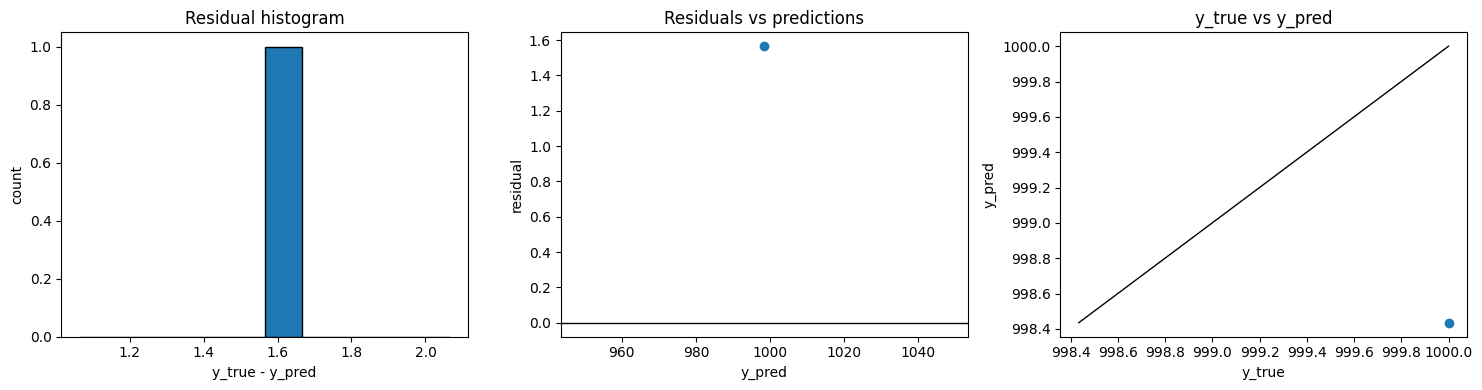

Train metrics: {'mse': 4.308232357047019e-27, 'rmse': 6.563712636189231e-14, 'r2': 1.0}
Test metrics:  {'mse': 2.4500991619410004, 'rmse': 1.565279260049465, 'r2': nan}


In [9]:
residuals = y_test.to_numpy() - model_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residual histogram
axes[0].hist(residuals, bins=10, edgecolor="black")
axes[0].set_title("Residual histogram")
axes[0].set_xlabel("y_true - y_pred")
axes[0].set_ylabel("count")

# Residuals vs predictions
axes[1].scatter(model_pred, residuals)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals vs predictions")
axes[1].set_xlabel("y_pred")
axes[1].set_ylabel("residual")

# Parity plot
axes[2].scatter(y_test, model_pred)
min_v = float(min(y_test.min(), model_pred.min()))
max_v = float(max(y_test.max(), model_pred.max()))
axes[2].plot([min_v, max_v], [min_v, max_v], color="black", linewidth=1)
axes[2].set_title("y_true vs y_pred")
axes[2].set_xlabel("y_true")
axes[2].set_ylabel("y_pred")

plt.tight_layout()
plt.show()

# Lightweight overfitting check (train vs test)
train_pred = model.predict(X_train)
train_metrics = evaluate_regression(y_train, train_pred)
test_metrics = evaluate_regression(y_test, model_pred)

print("Train metrics:", train_metrics)
print("Test metrics: ", test_metrics)

if not np.isnan(test_metrics["r2"]) and test_metrics["r2"] < 0:
    print(
        "\nDebug checklist for negative R²: verify split correctness, ensure preprocessing is fit only on train, check for target leakage, and confirm train/test distributions are comparable."
    )